[Augmentation Visualizer](https://gemini.google.com/share/262de8898380)

In [1]:
import kornia.augmentation as K
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

### Mixup,CutMix,Cutout,Integrating Mixup / CutMix into a Training Loop

In [2]:
# 1 :- Image Classification -> Dog and Cat --> image classification --> (confidence level) --> Regularization
# 2. How it work
# -- lambada

### Mixup

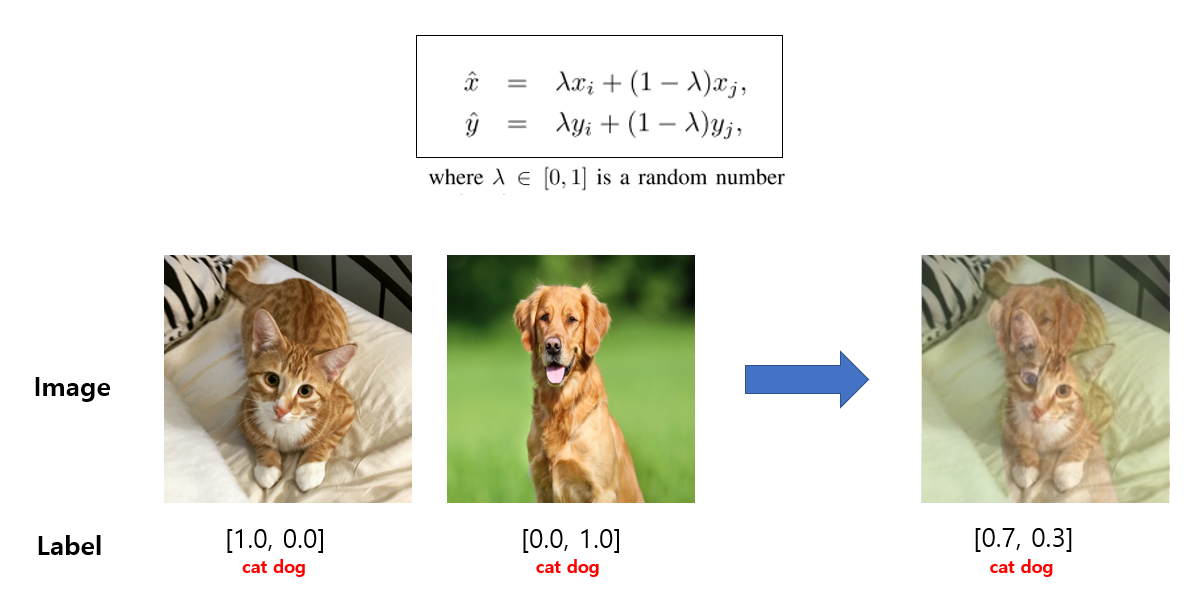

`mixed_image = lambda * x1 + (1 - lambda) * x2`

`mixed_label = lambda * y1 + (1 - lambda) * y2`

In [3]:
import torch.nn.functional as F

def mixup_data(X,y,alpha=0.6,num_classes = 3):
    lam = torch.distributions.Beta(alpha,alpha).sample().item() # Mix ratio 
    
    index = torch.randperm(X.size(0))
    mixed_x = lam * X + (1 - lam) * X[index]

    y_a = F.one_hot(y , num_classes=num_classes).float()
    y_b = F.one_hot(y[index] , num_classes=num_classes).float()

    mixed_y = lam * y_a + (1 - lam) * y_b

    return mixed_x , mixed_y , lam

In [4]:
to_tensor_ds = ImageFolder(
    root="./data/tiny-imagenet-200/train/",
    transform=transforms.ToTensor()
)
 
loader_small = DataLoader(to_tensor_ds , batch_size=8 , shuffle=True)

batch_imgs , batch_labels = next(iter(loader_small))
mixed_imgs , mixed_labels  , lam = mixup_data(batch_imgs , batch_labels)

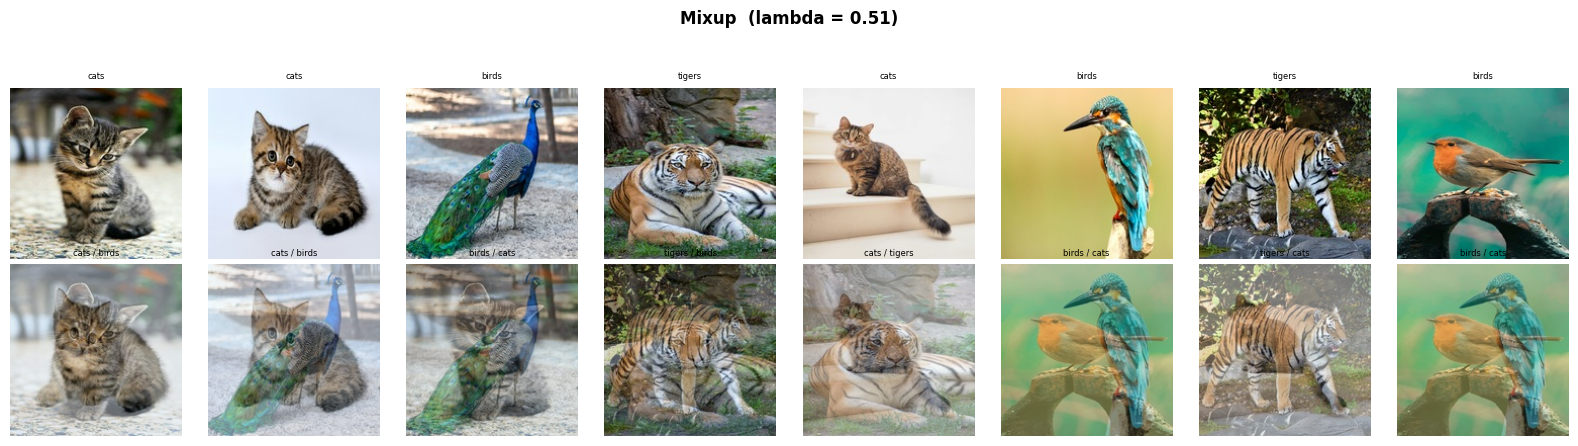

In [5]:
# Visulization

fig, axs = plt.subplots(2, 8, figsize=(16, 4.5))
fig.suptitle(f'Mixup  (lambda = {lam:.2f})', fontsize=12, fontweight='bold')

for i in range(8):
    axs[0, i].imshow(batch_imgs[i].permute(1, 2, 0).numpy())
    # ImageFolder stores class names as folder names (e.g., 'n01443537')
    axs[0, i].set_title(to_tensor_ds.classes[batch_labels[i].item()], fontsize=6)
    axs[0, i].axis('off')

    axs[1, i].imshow(mixed_imgs[i].permute(1, 2, 0).numpy())
    top2 = mixed_labels[i].topk(2).indices
    label_str = f"{to_tensor_ds.classes[top2[0].item()]} / {to_tensor_ds.classes[top2[1].item()]}"
    axs[1, i].set_title(label_str, fontsize=6)
    axs[1, i].axis('off')

axs[0, 0].set_ylabel('Original', fontsize=9)
axs[1, 0].set_ylabel('Mixed',    fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

### CutMix

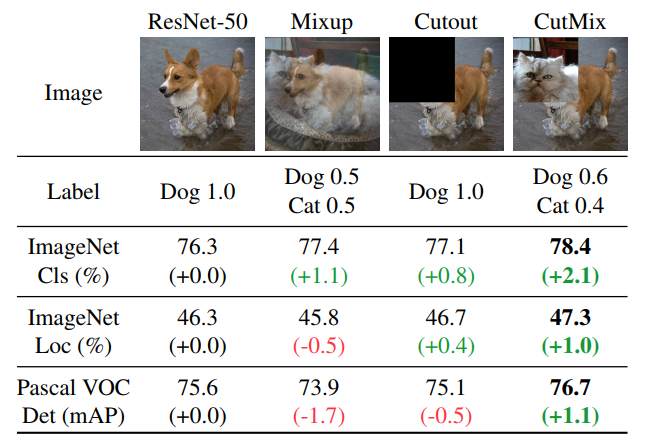

In [9]:
def cutmix_data(x,y,alpha=1,num_classes = 3):

    lam = torch.distributions.Beta(alpha,alpha).sample().item() # Mix ratio 
    
    index = torch.randperm(x.size(0))
    _ , C , H , W = x.shape

    # Compute cut region
    cut_ratio = np.sqrt(1.0 - lam)
    cut_h = int(H * cut_ratio)
    cut_w = int(W * cut_ratio)
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    
    # Top-left coordinates (clipped at 0 so they don't go off-screen)
    x1 = max(cx - cut_w // 3, 0)
    y1 = max(cy - cut_h // 3, 0)

    # Bottom-right coordinates (Fixed: use + and min() to clip at W and H)
    x2 = min(cx + cut_w // 3, W)
    y2 = min(cy + cut_h // 3, H)
    mixed_x = x.clone()
    mixed_x[:,:,y1:y2,x1:x2] = x[index,:,y1:y2 , x1:x2]

    # adjust lambda to refect actual area ratio
    lam_actual = 1 - (x2 - x1) * (y2 - y1) / (W * H)

    y_a = F.one_hot(y , num_classes=num_classes).float()
    y_b = F.one_hot(y[index] , num_classes=num_classes).float()

    mixed_y = lam_actual * y_a + (1 - lam_actual) * y_b

    return mixed_x , mixed_y , lam_actual

In [10]:
cut_imgs , cut_labels  , cut_lam = cutmix_data(batch_imgs , batch_labels)

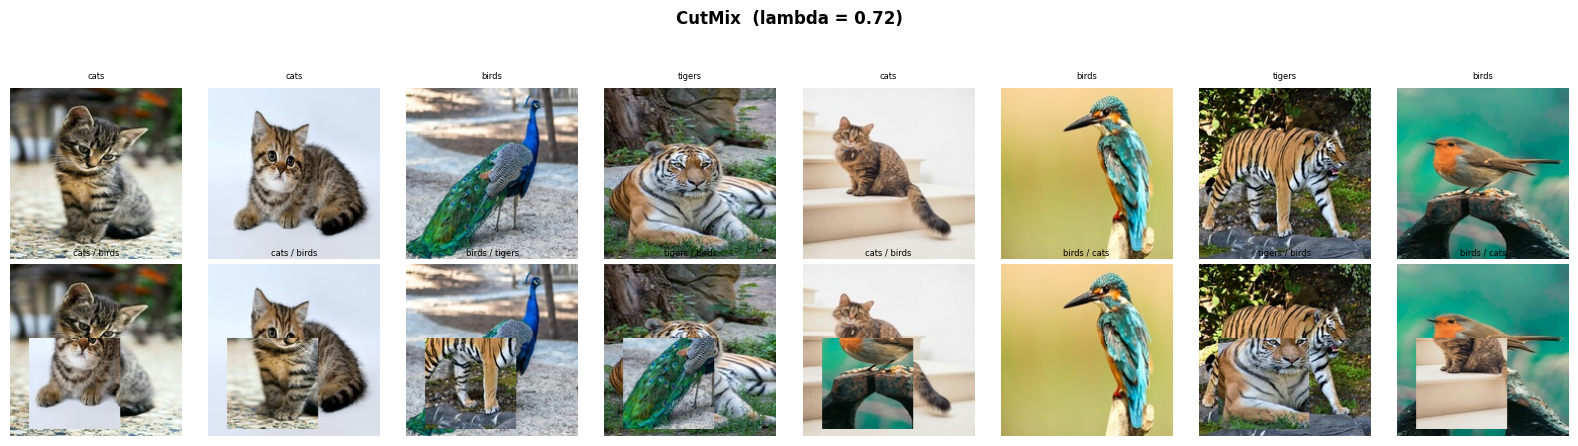

In [11]:
fig, axs = plt.subplots(2, 8, figsize=(16, 4.5))
fig.suptitle(f'CutMix  (lambda = {cut_lam:.2f})', fontsize=12, fontweight='bold')

for i in range(8):
    axs[0, i].imshow(batch_imgs[i].permute(1, 2, 0).numpy())
    axs[0, i].set_title(to_tensor_ds.classes[batch_labels[i].item()], fontsize=6)
    axs[0, i].axis('off')

    axs[1, i].imshow(cut_imgs[i].permute(1, 2, 0).numpy())
    top2 = cut_labels[i].topk(2).indices
    label_str = f"{to_tensor_ds.classes[top2[0].item()]} / {to_tensor_ds.classes[top2[1].item()]}"
    axs[1, i].set_title(label_str, fontsize=6)
    axs[1, i].axis('off')

axs[0, 0].set_ylabel('Original',  fontsize=9)
axs[1, 0].set_ylabel('CutMixed',  fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()